<a href="https://colab.research.google.com/github/SathyaPrakashD/Classical-ML-Pipeline/blob/main/sklearn_winequality_workout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================

from sklearn.datasets import load_digits
import pandas as pd

# Step 1 — Load the dataset
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')
#df = pd.DataFrame(data.data, columns=data.feature_names)


# Step 3 — Add the target column
#df['target'] = data.target

#print(df.head(5))


# Step 4 — Print basic info
print("Shape:", df.shape)          # how many rows and columns?
#print("Classes:", data.target_names)        # what are the 3 wine classes called?
print("Class counts:\n", df['quality'].value_counts())

# Step 5 — Preview first 5 rows
#print(df.___)jacob

Shape: (1599, 12)
Class counts:
 quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [8]:
# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['quality'])
y = df['quality']

print(X.shape)
print(y.shape)

(1599, 11)
(1599,)


In [10]:

# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['quality'])
y = df['quality']

# Step 2 — Split BEFORE scaling
# test_size=0.2 means 20% test, 80% train
# random_state fixes the random split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on TRAIN only
scaler = StandardScaler()
scaler.fit(X_train)             # learns mean & std from train only

# Step 4 — Transform both using train's stats
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)



# Step 5 — Verify scaling worked
X_train_df_before = pd.DataFrame(X_train, columns=X.columns)
print("\nBefore scaling (train set):")
print(X_train_df_before.head())

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df.head())
#print(X_train_df[['alcohol', 'magnesium', 'proline']].describe().round(2))

Train size: 1279
Test size: 320

Before scaling (train set):
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
493            8.7             0.690         0.31             3.0      0.086   
354            6.1             0.210         0.40             1.4      0.066   
342           10.9             0.390         0.47             1.8      0.118   
834            8.8             0.685         0.26             1.6      0.088   
705            8.4             1.035         0.15             6.0      0.073   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
493                 23.0                  81.0  1.00020  3.48       0.74   
354                 40.5                 165.0  0.99120  3.25       0.59   
342                  6.0                  14.0  0.99820  3.30       0.75   
834                 16.0                  23.0  0.99694  3.32       0.47   
705                 11.0                  54.0  0.99900  3.37       0.49   

 

In [11]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Step 1 — Create the model
model = LogisticRegression(max_iter=200)   # try 200 to start

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled,y_train)   # Model learns patterns and relationships

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)   #

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
#print((X_test_scaled)[0])
print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

Accuracy: 0.575

First test sample — true label   : 6
First test sample — predicted    : 5
First test sample — probabilities: [0.001 0.025 0.621 0.338 0.015 0.   ]


In [12]:

# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Step 2 — Run 5-fold cross validation on the FULL dataset
# Note: we use original X and y here, not the scaled versions
# The pipeline handles scaling safely inside each fold
scores = cross_val_score(pipeline, X, y, cv=5)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

Fold scores : [0.5188 0.5375 0.6312 0.5938 0.6301]
Mean accuracy: 0.5823
Std deviation: 0.0466


In [13]:
# ============================================================
# CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
# Note: Random Forest doesn't need scaling — but we keep it
# in the pipeline anyway for consistency. It won't hurt.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# Step 3 — Print both results side by side
print("Logistic Regression — mean: 0.5823  std: 0.0466")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Which model wins?
if rf_scores.mean() > scores.mean():
    print("\nRandom Forest wins!")
elif rf_scores.mean() < scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

Logistic Regression — mean: 0.5823  std: 0.0466
Random Forest       — mean: 0.5660  std: 0.0263

Logistic Regression wins!


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.63      0.75      0.69       130
           6       0.54      0.58      0.56       132
           7       0.39      0.21      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.57       320
   macro avg       0.43      0.27      0.28       320
weighted avg       0.56      0.57      0.55       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


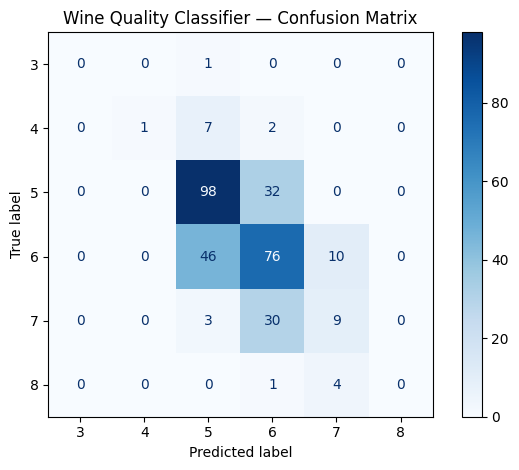

In [17]:
# ============================================================
# ROUND 1 — CHECKPOINT 6 — Full Evaluation Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Step 1 — Retrain best model (Logistic Regression) on train set
final_model = Pipeline(
    [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200))]
)
final_model.fit(X_train_scaled, y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test_scaled)

# Get unique class labels for target_names and display_labels
class_labels = sorted(y.unique().astype(str))

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title("Wine Quality Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 5 — New this round: extract the dangerous errors
# False Negatives = malignant predicted as benign
# These are the most dangerous mistakes in medical diagnosis
# The following section is commented out as it's designed for binary
# classification (0 and 1) and not directly applicable to multi-class
# wine quality prediction (ratings 3-8) without specific redefinition.
# y_test_arr = y_test.values
# false_negatives = sum(
#     1 for true, pred in zip(y_test_arr, y_pred)
#     if true == 0 and pred == 1
# )
# print(f"\nFalse Negatives (malignant \u2192 predicted benign): {false_negatives}")
# print(f"Out of {sum(y_test_arr == 0)} actual malignant cases")


## use class_weight='balanced' in sklearn tells model to pay more attention to rare classes during training

## Round -2

In [18]:
# ============================================================
# Round 2 - CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Step 1 — Create the model
model = LogisticRegression(max_iter=1000, class_weight='balanced')   # try 200 to start

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled,y_train)   # Model learns patterns and relationships

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)   #

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
#print((X_test_scaled)[0])
print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

Accuracy: 0.4313

First test sample — true label   : 6
First test sample — predicted    : 5
First test sample — probabilities: [0.005 0.168 0.523 0.278 0.025 0.001]


In [19]:

# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Step 2 — Run 5-fold cross validation on the FULL dataset
# Note: we use original X and y here, not the scaled versions
# The pipeline handles scaling safely inside each fold
scores = cross_val_score(pipeline, X, y, cv=5)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

Fold scores : [0.4312 0.3812 0.4031 0.35   0.4451]
Mean accuracy: 0.4022
Std deviation: 0.0342


In [20]:
# ============================================================
# CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
# Note: Random Forest doesn't need scaling — but we keep it
# in the pipeline anyway for consistency. It won't hurt.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# Step 3 — Print both results side by side
print("Logistic Regression — mean: 0.5823  std: 0.0466")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Which model wins?
if rf_scores.mean() > scores.mean():
    print("\nRandom Forest wins!")
elif rf_scores.mean() < scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

Logistic Regression — mean: 0.5823  std: 0.0466
Random Forest       — mean: 0.5710  std: 0.0209

Random Forest wins!


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.10      0.50      0.17        10
           5       0.66      0.52      0.58       130
           6       0.67      0.33      0.44       132
           7       0.39      0.43      0.41        42
           8       0.10      0.80      0.18         5

    accuracy                           0.43       320
   macro avg       0.32      0.43      0.30       320
weighted avg       0.60      0.43      0.48       320



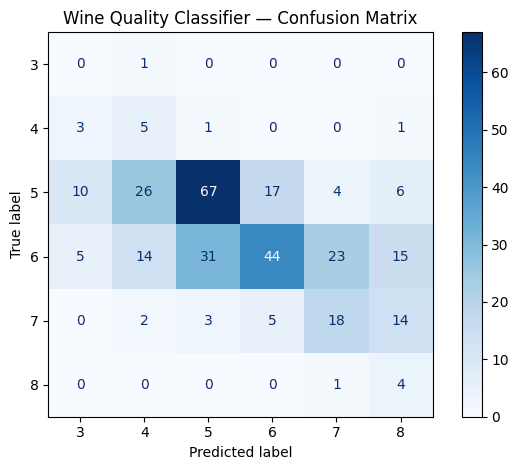

In [21]:
# ============================================================
# ROUND 1 — CHECKPOINT 6 — Full Evaluation Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Step 1 — Retrain best model (Logistic Regression) on train set
final_model = Pipeline(
    [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200,class_weight='balanced'))]
)
final_model.fit(X_train_scaled, y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test_scaled)

# Get unique class labels for target_names and display_labels
class_labels = sorted(y.unique().astype(str))

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title("Wine Quality Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 5 — New this round: extract the dangerous errors
# False Negatives = malignant predicted as benign
# These are the most dangerous mistakes in medical diagnosis
# The following section is commented out as it's designed for binary
# classification (0 and 1) and not directly applicable to multi-class
# wine quality prediction (ratings 3-8) without specific redefinition.
# y_test_arr = y_test.values
# false_negatives = sum(
#     1 for true, pred in zip(y_test_arr, y_pred)
#     if true == 0 and pred == 1
# )
# print(f"\nFalse Negatives (malignant \u2192 predicted benign): {false_negatives}")
# print(f"Out of {sum(y_test_arr == 0)} actual malignant cases")
